## `Week Four`

$$
\begin{equation}
I = \int_{\mathbb{R}^2} \text{exp}  (-(x^2+y^2)^2  ) dxdy
\end{equation}
$$
解析解为$\frac{{\pi}^{\frac{3}{2}}}{2}$

#### 方便的伪随机数生成方法

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
def integ(x, y):
    return np.exp(-(x**2 + y**2)**2)

def mc(f, x_range, y_range, num_samples):
    # 1. 采样语法：low, high, size
    x_samples = np.random.uniform(x_range[0], x_range[1], num_samples)
    y_samples = np.random.uniform(y_range[0], y_range[1], num_samples)
    
    # 2. 计算采样区域的面积
    area = (x_range[1] - x_range[0]) * (y_range[1] - y_range[0])
    
   
    est_result = area * np.mean(f(x_samples, y_samples))
    
    return est_result


x_range = [-10, 10]
y_range = [-10, 10]

num_samples_list = np.linspace(1000,100000,1000) 
theoretical_value = (np.pi ** 1.5) / 2
error_list =[]
result_list = []
for i in num_samples_list:
    result = mc(integ, x_range=x_range, y_range=y_range, num_samples= int(i))
    result_list.append(result)
    error = result - theoretical_value
    error_list.append(error)



_,(ax1,ax2) = plt.subplots(1,2,figsize=(10, 6))
ax1.plot(num_samples_list, error_list, label="error", color='blue',marker ='*')
ax1.set_xlabel("N samples")
ax1.set_ylabel("Monte Carlo Error")
ax1.legend()
ax2.plot(num_samples_list,result_list,label="Monte Carlo Value",color = 'green')
ax2.set_xlabel("N samples")
ax2.set_ylabel("Monte Carlo Value")
ax2.axhline(y=theoretical_value, color='red', linestyle='--', label="true value: ($\\frac{{\\pi}^{\\frac{3}{2}}}{2}$)")
ax2.legend()


#### 研究拒绝采样的Hyperparameter的影响
- 下面cell是老师的demo code

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 目标PDF：标准正态分布
def target_pdf(x):
    return np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)

# 高斯提议分布PDF（均值为0，标准差为proposal_std）
def proposal_pdf(x, proposal_std):
    return np.exp(-0.5 * (x / proposal_std)**2) / (proposal_std * np.sqrt(2 * np.pi))

# 拒绝采样实现
def rejection_sampling(target_pdf, proposal_pdf, M, proposal_std, n_samples):
    samples = []
    while len(samples) < n_samples:
        # 从高斯分布中采样
        x_star = np.random.normal(0, proposal_std)
        
        # 从均匀分布[0,1]中采样
        u = np.random.rand()
        
        # 拒绝采样的接受-拒绝条件
        if u * M * proposal_pdf(x_star, proposal_std) <= target_pdf(x_star):
            samples.append(x_star)
    return np.array(samples)

# 参数设置
proposal_std = 5  # 提议高斯分布的标准差
M = 11            # 根据最大 f(x)/g(x) 设置的上界（估计值）
n_samples = 10000

# 进行拒绝采样
samples = rejection_sampling(target_pdf, proposal_pdf, M, proposal_std, n_samples)

# 绘图
x = np.linspace(-5, 5, 1000)
target_vals = target_pdf(x)
proposal_vals = proposal_pdf(x, proposal_std)
scaled_proposal = M * proposal_vals

plt.figure(figsize=(8, 6))
plt.hist(samples, bins=50, density=True, alpha=0.6, label='Rejection Sampling Samples')
plt.plot(x, target_vals, 'r-', lw=2, label='Target PDF (Standard Normal)')
plt.plot(x, scaled_proposal, 'g--', lw=2, label='Scaled Proposal PDF (M × g(x))')
plt.title('Rejection Sampling using Gaussian Proposal')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


- 下面cell是修改后的code
- Hyperparameter也就`mu`, `sigma`

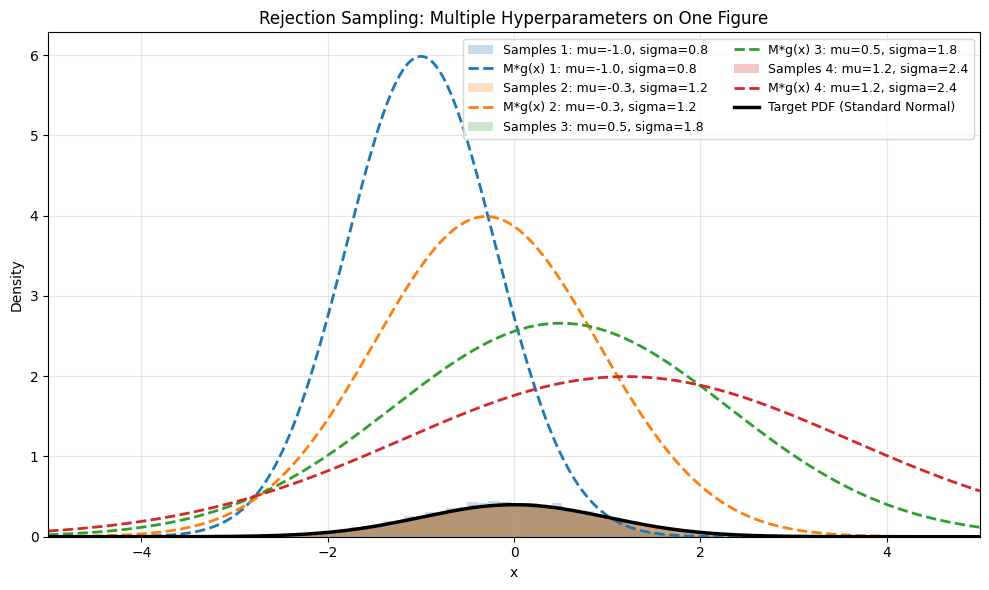

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 目标PDF：标准正态分布
def target_pdf(x):
    return np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)

# 高斯提议分布PDF（均值为mu，标准差为proposal_std）
def proposal_pdf(x, mu, proposal_std):
    return np.exp(-0.5 * ((x - mu) / proposal_std)**2) / (proposal_std * np.sqrt(2 * np.pi))

# 拒绝采样实现
def rejection_sampling(target_pdf, proposal_pdf, M, mu, proposal_std, n_samples):
    samples = []
    while len(samples) < n_samples:
        # 从提议分布 N(mu, proposal_std^2) 中采样
        x_star = np.random.normal(mu, proposal_std)

        # 从均匀分布[0,1]中采样
        u = np.random.rand()

        # 接受-拒绝条件
        if u * M * proposal_pdf(x_star, mu, proposal_std) <= target_pdf(x_star):
            samples.append(x_star)
    return np.array(samples)

# 参数设置：一组(mu, sigma)对应一种颜色
proposal_std_list = np.array([0.8, 1.2, 1.8, 2.4])
mu_list = np.array([-1.0, -0.3, 0.5, 1.2])
M = 12
n_samples = 10000

if len(proposal_std_list) != len(mu_list):
    raise ValueError("mu_list 与 proposal_std_list 长度必须一致")

# 采样
samples_list = []
for mu, proposal_std in zip(mu_list, proposal_std_list):
    samples = rejection_sampling(target_pdf, proposal_pdf, M, mu, proposal_std, n_samples)
    samples_list.append(samples)

# 单图叠加绘制
x = np.linspace(-5, 5, 1000)
target_vals = target_pdf(x)

# 显式构造 RGBA 元组列表，避免颜色被解释成标量
cmap = plt.get_cmap('tab10')
colors = [tuple(cmap(i % 10)) for i in range(len(mu_list))]

plt.figure(figsize=(10, 6))

for k, (mu, proposal_std, samples) in enumerate(zip(mu_list, proposal_std_list, samples_list)):
    color = colors[k]
    proposal_vals = proposal_pdf(x, mu, proposal_std)
    scaled_proposal = M * proposal_vals

    # 不同颜色的样本直方图
    plt.hist(
        samples,
        bins=60,
        density=True,
        alpha=0.25,
        color=color,
        label=f"Samples {k+1}: mu={mu:.1f}, sigma={proposal_std:.1f}"
    )

    # 对应的缩放提议分布曲线
    plt.plot(
        x,
        scaled_proposal,
        linestyle='--',
        linewidth=2,
        color=color,
        label=f"M*g(x) {k+1}: mu={mu:.1f}, sigma={proposal_std:.1f}"
    )

# 目标分布只画一次
plt.plot(x, target_vals, 'k-', linewidth=2.5, label='Target PDF (Standard Normal)')

plt.title('Rejection Sampling: Multiple Hyperparameters on One Figure')
plt.xlabel('x')
plt.ylabel('Density')
plt.xlim(-5, 5)
plt.grid(alpha=0.3)
plt.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

## `Week Five`

### HW1:

考虑一个目标分布 $p(x)$, 其概率密度函数为:

$$
p(x) = \frac{1}{Z} \exp\left(-\frac{x^4}{4}\right), \quad -\infty < x < \infty
$$

其中 $Z$ 是归一化常数, 用于确保 $p(x)$ 的积分为 1:

$$
Z = \int_{-\infty}^{\infty} \exp\left(-\frac{x^4}{4}\right) dx
$$

我们假设使用 Metropolis-Hastings 算法从该目标分布中采样, 提议分布为标准正态分布 $q(y|x) = \mathcal{N}(x, \sigma^2)$, 即从当前状态 $x_t$ 生成候选值 $y$。


画出生成的分布, 并对比目标分布。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma
from scipy.stats import norm
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像时负号'-'显示为方块的问题
# ==================== 第一题：Metropolis-Hastings算法 ====================
print("=" * 60)
print("第一题：Metropolis-Hastings算法")
print("=" * 60)

# 定义目标分布（未归一化）
def target_distribution_unnormalized(x):
    """目标分布（未归一化）"""
    return np.exp(-x**4 / 4)

# 计算归一化常数 Z
def compute_Z():
    """
    Z = ∫exp(-x^4/4)dx from -∞ to ∞
    通过变量替换，可以得到：Z = 2 * Γ(1/4) / 4^(1/4)
    """
    return 2 * gamma(1/4) / (4**(1/4))

Z = compute_Z()
print(f"归一化常数 Z = {Z:.4f}")

# 归一化的目标分布
def target_distribution(x):
    """归一化的目标分布"""
    return target_distribution_unnormalized(x) / Z

# Metropolis-Hastings 算法
def metropolis_hastings(n_samples, sigma=1.0, burn_in=1000):
    """
    Metropolis-Hastings 采样
    
    参数:
        n_samples: 采样数量
        sigma: 提议分布的标准差
        burn_in: 预烧期样本数
    """
    samples = []
    x_current = 0  # 初始值
    accepted = 0
    
    for i in range(n_samples + burn_in):
        # 从提议分布 N(x_current, sigma^2) 中采样
        x_proposed = np.random.normal(x_current, sigma)
        
        # 计算接受概率
        # 由于提议分布是对称的，所以 Hastings 比率为 1
        log_alpha = (np.log(target_distribution_unnormalized(x_proposed)) - 
                     np.log(target_distribution_unnormalized(x_current)))
        
        # 接受或拒绝
        if np.log(np.random.random()) < log_alpha:
            x_current = x_proposed
            if i >= burn_in:
                accepted += 1
        
        # 收集样本（跳过预烧期）
        if i >= burn_in:
            samples.append(x_current)
    
    acceptance_rate = accepted / n_samples
    return np.array(samples), acceptance_rate

# 运行 M-H 算法
np.random.seed(42)
n_samples = 10000
sigma = 1.0
samples, acceptance_rate = metropolis_hastings(n_samples, sigma)

print(f"采样数量: {n_samples}")
print(f"接受率: {acceptance_rate:.2%}")
print(f"样本均值: {np.mean(samples):.4f}")
print(f"样本标准差: {np.std(samples):.4f}")

# 可视化结果
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 图1: 样本分布直方图 vs 理论分布
x = np.linspace(-3, 3, 1000)
axes[0].hist(samples, bins=50, density=True, alpha=0.6, label='M-H 样本', color='skyblue')
axes[0].plot(x, target_distribution(x), 'r-', linewidth=2, label='理论分布')
axes[0].set_xlabel('x')
axes[0].set_ylabel('概率密度')
axes[0].set_title('Metropolis-Hastings 采样结果')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 图2: 样本的自相关图
lags = min(100, len(samples) // 10)
autocorr = np.correlate(samples - np.mean(samples), samples - np.mean(samples), mode='full')
autocorr = autocorr[len(autocorr)//2:]
autocorr = autocorr / autocorr[0]
axes[1].plot(range(lags), autocorr[:lags], 'b-', linewidth=1)
axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[1].set_xlabel('滞后')
axes[1].set_ylabel('自相关系数')
axes[1].set_title('样本自相关')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mh_sampling.png', dpi=300)
plt.show()


#### kimi code
- 因为其实没有必要算$Z$

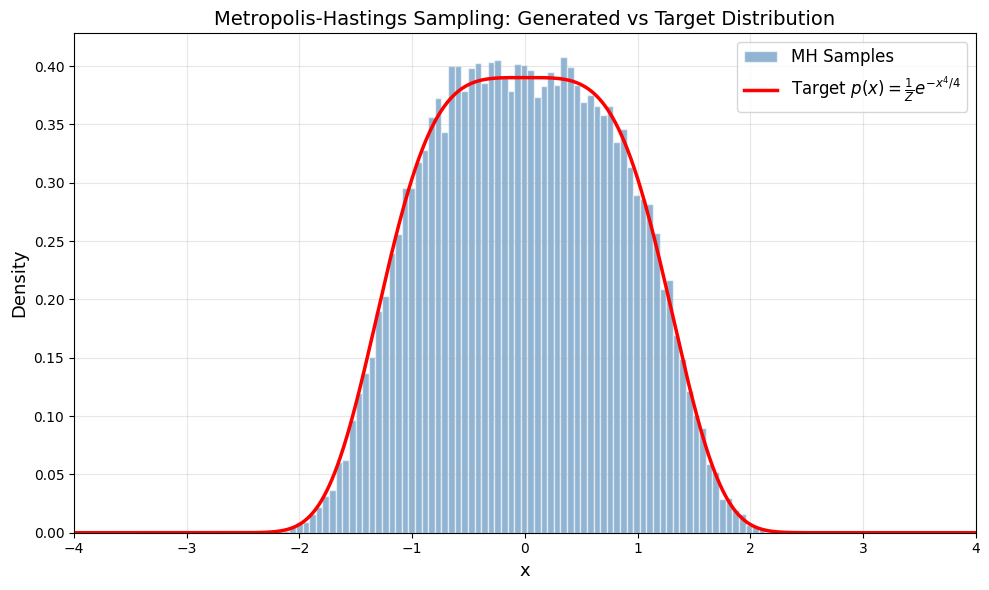

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 目标分布的未归一化密度 p(x) ~ exp(-x^4 / 4)
def target_unnormalized(x):
    return np.exp(-x**4 / 4)

# Metropolis-Hastings 采样
# 提议分布 q(y|x) = N(x, sigma^2)，对称，故 Hastings 比率为 1
def mh_sampler(n_samples=100000, sigma=2.0, x0=0.0, burn_in=10000):
    samples = []
    x = x0
    for i in range(n_samples + burn_in):
        # 从 N(x, sigma^2) 提议候选点
        y = np.random.normal(x, sigma)
        
        # 计算接受概率 A = min(1, p(y)/p(x))
        # Z 在分子分母中抵消，直接用未归一化密度
        log_ratio = (-y**4 / 4) - (-x**4 / 4)
        A = min(1.0, np.exp(log_ratio))
        
        # 以概率 A 接受
        if np.random.rand() < A:
            x = y
        
        if i >= burn_in:
            samples.append(x)
    
    return np.array(samples)

# 运行采样
samples = mh_sampler(n_samples=120000, sigma=2.0, x0=0.0, burn_in=20000)

# 绘图
fig, ax = plt.subplots(figsize=(10, 6))

# 样本直方图
ax.hist(samples, bins=80, density=True, alpha=0.6, color='steelblue',
        edgecolor='white', label='MH Samples')

# 目标分布的理论曲线（用 np.sum * dx 数值积分算 Z，跨版本兼容）
x_plot = np.linspace(-4, 4, 1000)
p_unnorm = np.exp(-x_plot**4 / 4)
dx = x_plot[1] - x_plot[0]
Z_numeric = np.sum(p_unnorm) * dx   # Riemann 和，等价于梯形积分
p_true = p_unnorm / Z_numeric

ax.plot(x_plot, p_true, 'r-', lw=2.5,
        label=r'Target $p(x)=\frac{1}{Z}e^{-x^4/4}$')

ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('Metropolis-Hastings Sampling: Generated vs Target Distribution',
             fontsize=14)
ax.legend(fontsize=12)
ax.set_xlim(-4, 4)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### HW2


- 考虑拟合函数（三参数理论模型）为 $y = ax^2 + bx + c$
- 生成一组观测数据 $(x_i, y_i)$，其中 $y_i$ 是具有高斯噪声的观测值，$y_i = ax_i^2 + bx_i + c + n_i$
- 使用贝叶斯推断来估计函数参数 a, b, c 的置信区间（真值是 1, 1, 1）。
- 利用先验知识和观测数据的似然函数，计算参数的后验分布

$\textcolor{red}{注意:运行下面的cell之前需要运行上面的Cell}$

In [ ]:

# ==================== 第二题：贝叶斯推断 ====================
print("\n" + "=" * 60)
print("第二题：贝叶斯推断估计二次函数参数")
print("=" * 60)

# 生成观测数据
np.random.seed(123)
n_points = 50
x_data = np.linspace(-2, 2, n_points)
a_true, b_true, c_true = 1, 1, 1
noise_std = 0.5
noise = np.random.normal(0, noise_std, n_points)
y_data = a_true * x_data**2 + b_true * x_data + c_true + noise

print(f"数据点数量: {n_points}")
print(f"真实参数: a={a_true}, b={b_true}, c={c_true}")
print(f"噪声标准差: {noise_std}")

# 定义先验分布
def log_prior(a, b, c, sigma):
    """
    对数先验概率
    假设参数服从正态先验
    """
    # 宽松的正态先验
    log_p_a = norm.logpdf(a, loc=0, scale=10)
    log_p_b = norm.logpdf(b, loc=0, scale=10)
    log_p_c = norm.logpdf(c, loc=0, scale=10)
    # sigma 的正态先验（确保为正）
    if sigma <= 0:
        return -np.inf
    log_p_sigma = norm.logpdf(sigma, loc=1, scale=2)
    
    return log_p_a + log_p_b + log_p_c + log_p_sigma

# 定义似然函数
def log_likelihood(a, b, c, sigma, x, y):
    """
    对数似然函数
    假设观测噪声为高斯分布
    """
    y_pred = a * x**2 + b * x + c
    return np.sum(norm.logpdf(y - y_pred, loc=0, scale=sigma))

# 定义后验分布
def log_posterior(a, b, c, sigma, x, y):
    """对数后验概率 = 对数先验 + 对数似然"""
    lp = log_prior(a, b, c, sigma)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(a, b, c, sigma, x, y)

# MCMC 采样（Metropolis-Hastings）
def bayesian_mcmc(n_samples, x, y, burn_in=2000):
    """
    使用 M-H 算法进行贝叶斯推断
    """
    # 初始化参数
    a, b, c, sigma = 0.5, 0.5, 0.5, 1.0
    samples = []
    current_posterior = log_posterior(a, b, c, sigma, x, y)
    
    # 提议分布的步长
    step_sizes = [0.1, 0.1, 0.1, 0.05]
    
    for i in range(n_samples + burn_in):
        # 提议新参数
        a_prop = a + np.random.normal(0, step_sizes[0])
        b_prop = b + np.random.normal(0, step_sizes[1])
        c_prop = c + np.random.normal(0, step_sizes[2])
        sigma_prop = sigma + np.random.normal(0, step_sizes[3])
        
        # 确保 sigma > 0
        if sigma_prop <= 0:
            samples.append([a, b, c, sigma])
            continue
        
        # 计算接受概率
        new_posterior = log_posterior(a_prop, b_prop, c_prop, sigma_prop, x, y)
        log_alpha = new_posterior - current_posterior
        
        # 接受或拒绝
        if np.log(np.random.random()) < log_alpha:
            a, b, c, sigma = a_prop, b_prop, c_prop, sigma_prop
            current_posterior = new_posterior
        
        # 收集样本
        if i >= burn_in:
            samples.append([a, b, c, sigma])
    
    return np.array(samples)

# 运行贝叶斯 MCMC
print("\n正在进行 MCMC 采样...")
n_samples = 10000
mcmc_samples = bayesian_mcmc(n_samples, x_data, y_data, burn_in=2000)

# 提取参数样本
a_samples = mcmc_samples[:, 0]
b_samples = mcmc_samples[:, 1]
c_samples = mcmc_samples[:, 2]
sigma_samples = mcmc_samples[:, 3]

# 计算统计量
def compute_statistics(samples, name):
    mean = np.mean(samples)
    std = np.std(samples)
    ci_lower = np.percentile(samples, 2.5)
    ci_upper = np.percentile(samples, 97.5)
    print(f"\n{name}:")
    print(f"  后验均值: {mean:.4f}")
    print(f"  后验标准差: {std:.4f}")
    print(f"  95% 置信区间: [{ci_lower:.4f}, {ci_upper:.4f}]")
    return mean, std, ci_lower, ci_upper

print("\n参数估计结果:")
a_mean, a_std, a_ci_lower, a_ci_upper = compute_statistics(a_samples, '参数 a')
b_mean, b_std, b_ci_lower, b_ci_upper = compute_statistics(b_samples, '参数 b')
c_mean, c_std, c_ci_lower, c_ci_upper = compute_statistics(c_samples, '参数 c')
sigma_mean, sigma_std, _, _ = compute_statistics(sigma_samples, '噪声标准差 σ')

# 可视化结果
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. 数据点和拟合曲线
axes[0, 0].scatter(x_data, y_data, alpha=0.6, label='观测数据', color='blue')
x_fit = np.linspace(-2.5, 2.5, 100)
y_fit = a_mean * x_fit**2 + b_mean * x_fit + c_mean
y_true = a_true * x_fit**2 + b_true * x_fit + c_true
axes[0, 0].plot(x_fit, y_fit, 'r-', linewidth=2, label='贝叶斯拟合')
axes[0, 0].plot(x_fit, y_true, 'g--', linewidth=2, label='真实曲线')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y')
axes[0, 0].set_title('数据拟合结果')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. 参数 a 的后验分布
axes[0, 1].hist(a_samples, bins=50, density=True, alpha=0.7, color='skyblue')
axes[0, 1].axvline(a_true, color='red', linestyle='--', linewidth=2, label=f'真实值: {a_true}')
axes[0, 1].axvline(a_mean, color='blue', linestyle='-', linewidth=2, label=f'后验均值: {a_mean:.3f}')
axes[0, 1].axvspan(a_ci_lower, a_ci_upper, alpha=0.3, color='green', label='95% CI')
axes[0, 1].set_xlabel('a')
axes[0, 1].set_ylabel('密度')
axes[0, 1].set_title('参数 a 的后验分布')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. 参数 b 的后验分布
axes[0, 2].hist(b_samples, bins=50, density=True, alpha=0.7, color='lightcoral')
axes[0, 2].axvline(b_true, color='red', linestyle='--', linewidth=2, label=f'真实值: {b_true}')
axes[0, 2].axvline(b_mean, color='blue', linestyle='-', linewidth=2, label=f'后验均值: {b_mean:.3f}')
axes[0, 2].axvspan(b_ci_lower, b_ci_upper, alpha=0.3, color='green', label='95% CI')
axes[0, 2].set_xlabel('b')
axes[0, 2].set_ylabel('密度')
axes[0, 2].set_title('参数 b 的后验分布')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. 参数 c 的后验分布
axes[1, 0].hist(c_samples, bins=50, density=True, alpha=0.7, color='lightgreen')
axes[1, 0].axvline(c_true, color='red', linestyle='--', linewidth=2, label=f'真实值: {c_true}')
axes[1, 0].axvline(c_mean, color='blue', linestyle='-', linewidth=2, label=f'后验均值: {c_mean:.3f}')
axes[1, 0].axvspan(c_ci_lower, c_ci_upper, alpha=0.3, color='green', label='95% CI')
axes[1, 0].set_xlabel('c')
axes[1, 0].set_ylabel('密度')
axes[1, 0].set_title('参数 c 的后验分布')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. MCMC 采样轨迹
axes[1, 1].plot(a_samples[:500], label='a', alpha=0.7)
axes[1, 1].plot(b_samples[:500], label='b', alpha=0.7)
axes[1, 1].plot(c_samples[:500], label='c', alpha=0.7)
axes[1, 1].axhline(a_true, color='blue', linestyle='--', alpha=0.5)
axes[1, 1].axhline(b_true, color='orange', linestyle='--', alpha=0.5)
axes[1, 1].axhline(c_true, color='green', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('样本索引')
axes[1, 1].set_ylabel('参数值')
axes[1, 1].set_title('MCMC 采样轨迹（前500个样本）')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. 参数联合分布（a vs b）
scatter = axes[1, 2].scatter(a_samples[::10], b_samples[::10], alpha=0.5, s=10)
axes[1, 2].axvline(a_true, color='red', linestyle='--', alpha=0.5)
axes[1, 2].axhline(b_true, color='red', linestyle='--', alpha=0.5)
axes[1, 2].plot(a_mean, b_mean, 'yo', markersize=10, label='后验均值')
axes[1, 2].set_xlabel('a')
axes[1, 2].set_ylabel('b')
axes[1, 2].set_title('参数 a 和 b 的联合后验分布')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bayesian_inference.png', dpi=300)
plt.show()

print("\n" + "=" * 60)
print("所有图形已保存为 'mh_sampling.png' 和 'bayesian_inference.png'")
print("=" * 60)

## `Week Six`

### 用上面宇宙微波背景辐射的图，
1、加上高通滤波，图像和功率谱变成什么样子？

2、加上低通滤波，图像和功率谱变成什么样子？

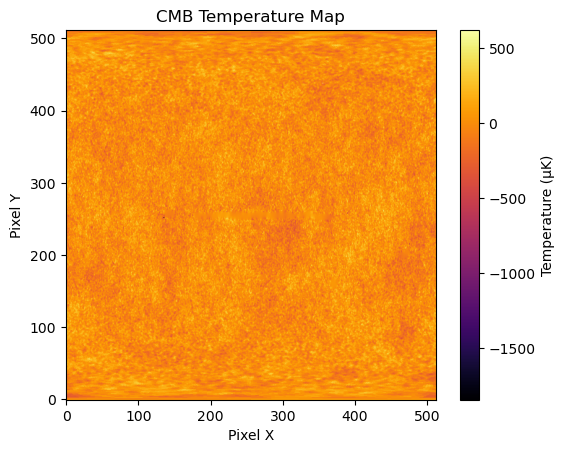

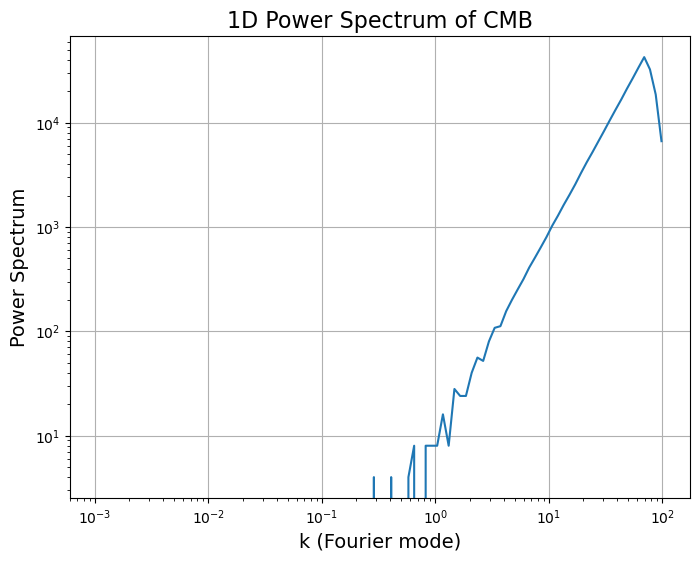

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load the 2D CMB map from the .npy file
cmb_2d_map = np.load('cmb_2d_map.npy')

# Load the 2D CMB map from the .npy file
cmb_2d_map = np.load('cmb_2d_map.npy')


plt.imshow(cmb_2d_map, cmap='inferno', origin='lower', aspect=1)
plt.colorbar(label='Temperature (µK)')
plt.title('CMB Temperature Map')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.show()

# Perform 2D FFT on the original map
fft_cmb = np.fft.fftshift(np.fft.fft2(cmb_2d_map))

# Calculate the power spectrum (magnitude squared of the FFT)
power_spectrum = np.abs(fft_cmb)**2

# Get the shape of the map
ny, nx = cmb_2d_map.shape

res=np.pi/180*(40000/nx/ny)**0.5
# Create a grid of (u, v) Fourier modes
u = np.fft.fftfreq(nx, res)  # Fourier frequencies in the x direction
v = np.fft.fftfreq(ny, res)  # Fourier frequencies in the y direction
u, v = np.meshgrid(u, v)  # Create a meshgrid for 2D Fourier modes

# Calculate the radial distance in Fourier space
k = np.sqrt(u**2 + v**2)  # The radial frequency

# Flatten the power spectrum and k arrays for histogramming
k_flat = k.flatten()
power_spectrum_flat = power_spectrum.flatten()

# Define the number of bins (logarithmic binning)
num_bins = 100

# Avoid zero or very small values in k_min and k_max
k_min = np.min(k_flat)
k_max = np.max(k_flat)

# Set a minimum threshold for k_min to avoid log10(0) errors
k_min = max(k_min, 1e-3)

# Logarithmic binning for k values
bins = np.logspace(np.log10(k_min), np.log10(k_max), num_bins)

# Use np.histogram2d to bin the data
hist, xedges, yedges = np.histogram2d(k_flat, power_spectrum_flat, bins=[bins, np.logspace(np.log10(np.min(power_spectrum_flat)), np.log10(np.max(power_spectrum_flat)), num_bins)])

# Calculate the bin centers for k and power spectrum
bin_centers_k = 0.5 * (xedges[1:] + xedges[:-1])

# Plot the 1D power spectrum (averaging the histogram values)
plt.figure(figsize=(8, 6))
plt.loglog(bin_centers_k, np.sum(hist, axis=1))  # Sum across the power spectrum bins
plt.xlabel('k (Fourier mode)', fontsize=14)
plt.ylabel('Power Spectrum', fontsize=14)
plt.title('1D Power Spectrum of CMB', fontsize=16)
plt.grid(True)
plt.show()

整个流程可以概括为一句话：**把图像搬到频率空间，按“距离中心的远近”把频率切成环，统计每个环的平均功率得到 1D 谱；再用这个距离做遮罩，只保留想要的频率环，最后搬回图像空间。**

下面按代码顺序逐步拆解，重点放在的 **1D 功率谱** 部分。

---

### 1. 从图像到频率空间：二维 FFT

```python
fft = np.fft.fftshift(np.fft.fft2(cmb))
```

- `fft2`：把 $N_x \times N_y$ 的实空间图像 $T(x,y)$ 变换到频率空间 $\hat T(k_x, k_y)$。
- `fftshift`：把零频（DC 分量，对应图像的平均温度）从四角挪到**数组正中心**。

此时 `fft` 是一个复数矩阵。中心点是 $(k_x,k_y)=(0,0)$，越远离中心，代表的空间频率 $|\mathbf k|=\sqrt{k_x^2+k_y^2}$ 越高，对应实空间中越**精细**的结构。

---

### 2. 径向距离矩阵 `r`：频率空间的“极坐标半径”

```python
y, x = np.ogrid[:ny, :nx]
r = np.sqrt((x - nx//2)**2 + (y - ny//2)**2).flatten()
```

这里构建了一个与 `fft` 同形状的矩阵 `r`，其每个元素的值等于该像素到**中心**（零频）的欧氏距离。

| 位置 | 物理意义 |
|:---|:---|
| `r = 0` | 中心，零频，对应图像的**全局平均** |
| `r` 很小 | 低频，对应实空间中**大尺度**的起伏（比如 CMB 中几十度的温度斑块） |
| `r` 很大 | 高频，对应实空间中**小尺度**结构（比如像素级噪声、精细边缘） |

**关键点**：在频率空间里，“离中心越远” = “空间频率越高” = “实空间尺度越小”。

---

### 3. 1D 功率谱：把二维环形区域压成一维曲线

这是你问题最大的部分。先看代码：

```python
def get_1d_power(fft_2d, bins=50):
    p2d = np.abs(fft_2d)**2          # 2D 功率谱
    r_bins = np.linspace(1, np.max(r), bins)
    stats = binned_statistic(r, p2d.flatten(), statistic='mean', bins=r_bins)
    return r_bins[1:], stats.statistic
```

#### 为什么要这么做？

二维功率谱 `p2d` 是一个矩阵，每个像素有一个功率值。但很多时候我们只关心**“某个频率大小 $|\mathbf k|$ 上平均有多少功率”**，而不关心方向（即不区分是水平波纹还是竖直波纹）。

在频率平面上，**相同半径 $r$ 的点构成一个圆环**。如果我们把每个圆环上的所有功率值取平均，就得到了**各向同性**的 1D 功率谱 $P(k)$，其中 $k$ 就是半径 $r$。

#### `binned_statistic` 在做什么？

它本质上在执行：

$$
P(k_i) = \frac{1}{N_i}\sum_{j \in \text{bin } i} |\hat T_j|^2
$$

- 第一个参数 `r`：告诉函数“每个数据点所在的半径是多少”（相当于 x 坐标 / 分类依据）。
- 第二个参数 `p2d.flatten()`：告诉函数“每个数据点的功率值是多少”（待统计的数据）。
- `bins=r_bins`：把半径轴切成 50 个区间（从 1 到最大半径）。
- `statistic='mean'`：对每个半径区间（圆环）内的所有功率值求**平均**。

返回的 `stats.statistic` 是一个长度为 `bins-1` 的数组，每个元素就是一个圆环的平均功率。`r_bins[1:]` 取的是每个区间的**右端点**作为该环的代表半径 $k$。

#### 为什么 `r_bins` 从 1 开始而不是 0？

`np.linspace(1, ...)` 故意避开了 $r=0$ 的 DC 分量。因为零频功率通常是整个频谱的巨无霸（等于图像总亮度的平方），如果把它放进第一个 bin，会把整个 1D 谱的尺度拉变形，其他频率的细节就全被压没了。

---

### 4. 滤波掩码：低通 vs 高通

```python
r_mask = r.reshape(ny, nx)   # 把一维的 r 恢复成与 fft 同形状的 2D 矩阵

# 高通：只保留 r > cutoff 的频率
fft_hp = fft * (r_mask > cutoff)

# 低通：只保留 r < cutoff 的频率
fft_lp = fft * (r_mask < cutoff)
```

这里 `r_mask > cutoff` 是一个布尔矩阵（True/False），在频率空间上相当于一个**环形遮罩**：

- **低通滤波** `r < cutoff`：只保留中心附近的低频，滤掉外围高频。  
  效果：图像变得**平滑**，大尺度结构保留，小尺度噪声/细节被抹除。

- **高通滤波** `r > cutoff`：只保留外围的高频，把中心低频（包括全局平均）归零。  
  效果：图像只剩下**边缘和小尺度纹理**，大尺度背景被移除，整体看起来像是“浮雕”或“细节增强”。

---

### 5. 逆变换：从频率空间回到图像

```python
img_hp = np.real(np.fft.ifft2(np.fft.ifftshift(fft_hp)))
img_lp = np.real(np.fft.ifft2(np.fft.ifftshift(fft_lp)))
```

- `ifftshift`：把中心零频移回四角，与 `fftshift` 互逆。
- `ifft2`：二维逆傅里叶变换。
- `np.real(...)`：理论上对实数图像做对称滤波后，逆变换结果应该是纯实数。但由于浮点误差会产生 $10^{-16}$ 量级的虚部，所以取实部。

---

### 6. 功率谱对比图在说什么？

```python
plt.loglog(k, P_orig, 'k--', label='Original', alpha=0.5)
plt.loglog(k_lp, P_lp, 'r', lw=2, label='Low-Pass')
plt.loglog(k_hp, P_hp, 'b', lw=2, label='High-Pass')
```

- **黑虚线**：原始图像的 1D 功率谱 $P(k)$。CMB 的功率谱通常随 $k$ 增大而下降（大尺度功率强，小尺度功率弱）。
- **红线**：低通滤波后的谱。在 $k > \text{cutoff}$ 处应该突然跌落（被遮罩清零），$k < \text{cutoff}$ 处与原始谱重合。
- **蓝线**：高通滤波后的谱。在 $k < \text{cutoff}$ 处应该极低（中心被挖空），$k > \text{cutoff}$ 处与原始谱重合。

---

### 总结：物理直觉

| 步骤 | 操作 | 物理意义 |
|:---|:---|:---|
| 1 | `fft2` + `fftshift` | 把温度图分解成不同空间频率的平面波 |
| 2 | 计算 `r` | 给每个平面波标上“波长标签”（半径=频率大小） |
| 3 | `binned_statistic` | 把同波长的平面波功率取平均，得到 $P(k)$ |
| 4 | 环形遮罩 | 像切蛋糕一样，只保留想要波长范围的成分 |
| 5 | `ifft2` | 把选中的平面波重新叠加成图像 |



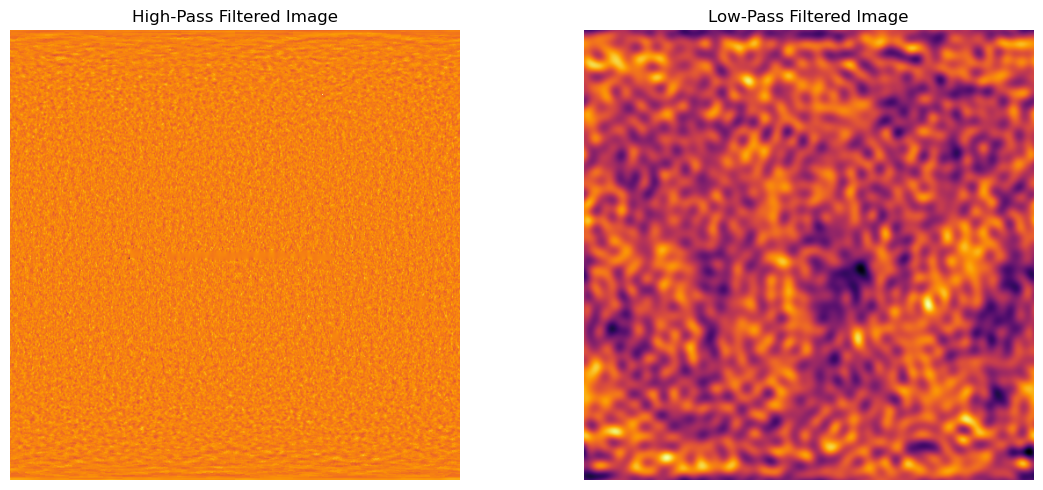

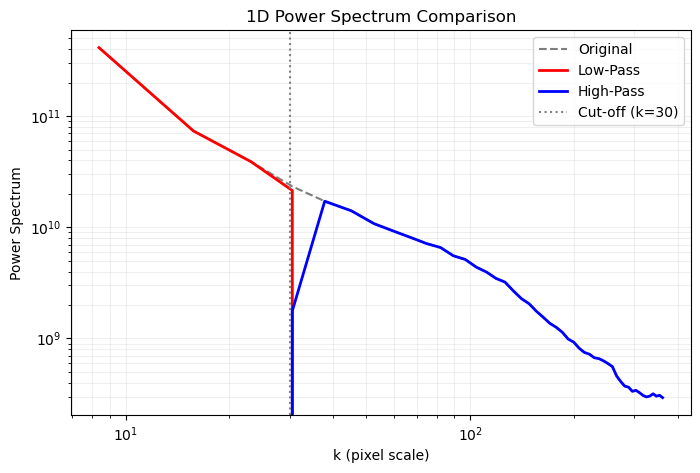

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

# 加载数据
cmb = np.load('cmb_2d_map.npy')
ny, nx = cmb.shape

# 核心计算：FFT与径向频率(像素单位)
fft = np.fft.fftshift(np.fft.fft2(cmb))
y, x = np.ogrid[:ny, :nx]
r = np.sqrt((x - nx//2)**2 + (y - ny//2)**2).flatten()

# 提取1D功率谱的简洁函数
def get_1d_power(fft_2d, bins=50):
    p2d = np.abs(fft_2d)**2
    r_bins = np.linspace(1, np.max(r), bins)
    stats = binned_statistic(r, p2d.flatten(), statistic='mean', bins=r_bins)
    return r_bins[1:], stats.statistic

k, P_orig = get_1d_power(fft)

# 设置滤波阈值（像素半径，可调整）
cutoff = 30 
r_mask = r.reshape(ny, nx)

# 高通滤波 (保留高频/小尺度结构)
fft_hp = fft * (r_mask > cutoff)
img_hp = np.real(np.fft.ifft2(np.fft.ifftshift(fft_hp)))

# 低通滤波 (保留低频/大尺度结构)
fft_lp = fft * (r_mask < cutoff)
img_lp = np.real(np.fft.ifft2(np.fft.ifftshift(fft_lp)))

k_hp, P_hp = get_1d_power(fft_hp)
k_lp, P_lp = get_1d_power(fft_lp)

# 可视化对比
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左图：图像对比
axes[0].imshow(img_hp, cmap='inferno', origin='lower', aspect=1)
axes[0].set_title('High-Pass Filtered Image')
axes[0].axis('off')

axes[1].imshow(img_lp, cmap='inferno', origin='lower', aspect=1)
axes[1].set_title('Low-Pass Filtered Image')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# 右图：功率谱对比
plt.figure(figsize=(8, 5))
plt.loglog(k, P_orig, 'k--', label='Original', alpha=0.5)
plt.loglog(k_lp, P_lp, 'r', lw=2, label='Low-Pass')
plt.loglog(k_hp, P_hp, 'b', lw=2, label='High-Pass')
plt.axvline(cutoff, color='gray', ls=':', label=f'Cut-off (k={cutoff})')
plt.xlabel('k (pixel scale)')
plt.ylabel('Power Spectrum')
plt.title('1D Power Spectrum Comparison')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()


### 作业2要求


#### 目标函数
给定矩阵 $M$ 和目标向量 $y$，我们要最小化以下目标函数：
$$f(x) = \|Mx - y\|^2$$
其中，$M$ 是一个 $n \times n$ 的矩阵，$x$ 是一个 $n$-维列向量，$y$ 是一个目标向量。

#### 约束条件
优化问题有以下约束条件：
- $x_i \geq 0$ 对于所有的 $x_i$，即解向量 $x$ 中的每个分量都必须非负。
- $\sum_{i=1}^{n} x_i^2 = 1$，即解向量 $x$ 必须满足单位约束。

我们需要找到满足约束条件的 $x$，使得目标函数 $f(x)$ 最小化。

#### 矩阵和目标向量的构造
- 矩阵 $M$：我们构造一个矩阵 $M$，其中每个元素 $M_{ij} = \cos(i + j)$，即矩阵的元素与行列索引之和的余弦值相关。
- 目标向量 $y$：我们构造目标向量 $y$，其中每个元素 $y_i = \sin(i) \cdot \cos(i)$，即目标向量的每个元素是 $\sin(i)$ 和 $\cos(i)$ 的乘积。

对于10×10 矩阵，最小值大概为：$1.0944491656790756$

In [3]:
import numpy as np
from scipy.optimize import minimize

# ===================== 1. 设置参数与构造矩阵/向量 =====================
n = 10  # 矩阵大小 (10x10)

# 构造矩阵 M: M[i][j] = cos(i + j)，其中 i, j 从 1 开始计数
M = np.zeros((n, n))
for i in range(1, n + 1):
    for j in range(1, n + 1):
        M[i-1, j-1] = np.cos(i + j)

# 构造目标向量 y: y[i] = sin(i) * cos(i)，其中 i 从 1 开始计数
y = np.zeros(n)
for i in range(1, n + 1):
    y[i-1] = np.sin(i) * np.cos(i)

# ===================== 2. 定义优化问题 =====================
# 目标函数: f(x) = ||Mx - y||^2
def objective(x):
    return np.linalg.norm(M @ x - y) ** 2

# 约束条件
# 等式约束: ||x||^2 = 1 (单位向量)
eq_constraint = {'type': 'eq', 'fun': lambda x: np.sum(x ** 2) - 1}
# 不等式约束: x_i >= 0 (非负)
ineq_constraint = {'type': 'ineq', 'fun': lambda x: x}

constraints = [eq_constraint, ineq_constraint]

# 初始猜测 (随机生成并归一化，保证满足单位约束)
np.random.seed(42)  # 固定随机种子以便复现
x0 = np.random.rand(n)
x0 = x0 / np.linalg.norm(x0)

# ===================== 3. 求解优化问题 =====================
# 使用 SLSQP 方法 (支持等式和不等式约束)
result = minimize(objective, x0, method='SLSQP', constraints=constraints)

# ===================== 4. 输出结果 =====================
print("优化是否成功:", result.success)
print("最优解 x (非负单位向量):\n", result.x)
print("最优值 f(x):", result.fun)
print("题目给出的参考最小值: 1.0944491656790756")

优化是否成功: True
最优解 x (非负单位向量):
 [6.87473004e-01 4.01714294e-05 2.94832640e-06 6.86791765e-01
 1.82699283e-01 7.91297805e-06 1.18816192e-01 9.05628467e-02
 5.01282341e-05 8.22725849e-06]
最优值 f(x): 1.3512032774654936
题目给出的参考最小值: 1.0944491656790756
